# Uncertainty Quantification in Systems Biology with pyPESTO

This tutorial introduces **uncertainty quantification (UQ)** for ODE-based mechanistic models using [pyPESTO](https://pypesto.readthedocs.io) — a Python toolbox for parameter estimation and uncertainty analysis.

We will work through three complementary UQ approaches:

| Method | Approach | What it gives you |
|---|---|---|
| **Multi-start optimization** | Frequentist | Point estimates + identifiability check |
| **Profile likelihood** | Frequentist | Confidence intervals per parameter |
| **MCMC sampling** | Bayesian | Full posterior distribution |

### Prerequisites
- Basic knowledge of ODE models and parameter estimation
- Familiarity with the [PEtab](https://petab.readthedocs.io) format (YAML + TSV files describing the estimation problem)

---

## Setup

Import the required libraries. `pypesto` provides all core functionality; `petab` handles model/data loading.

In [1]:
import copy

import matplotlib.pyplot as plt
import numpy as np

import petab

import pypesto
import pypesto.optimize as optimize
import pypesto.petab
import pypesto.profile as profile
import pypesto.sample as sample
import pypesto.visualize as visualize
from pypesto.visualize.model_fit import visualize_optimized_model_fit

---
## 1. Loading the PEtab Problem

Our estimation problem is described in [PEtab format](https://petab.readthedocs.io): a YAML file pointing to TSV files for the model (SBML), measurements, observables, conditions, and parameters.

```
petab_problem/
├── problem.yaml        ← entry point
├── model.xml           ← SBML ODE model
├── measurements.tsv
├── observables.tsv
├── conditions.tsv
└── parameters.tsv      ← bounds, priors, fixed flags
```

`PetabImporter` translates the PEtab problem into a pyPESTO `Problem` object, which bundles the objective function, parameter bounds, and any fixed parameters.

In [2]:
# Path to the PEtab YAML configuration file
petab_yaml = "./petab_problem/problem.yaml"

# Translate the PEtab problem into pyPESTO format
importer = pypesto.petab.PetabImporter.from_yaml(petab_yaml)

# Create the pyPESTO problem object
# (bundles objective function, parameter bounds, and fixed parameters)
problem = importer.create_problem(verbose=False)

print(f"Number of free parameters: {problem.dim}")
print(f"Parameter names: {problem.x_names}")

Visualization table not available. Skipping.


Number of free parameters: 2
Parameter names: ['k_ab', 'k_ba']


---
## 2. Multi-Start Optimization

Parameter estimation is a **non-convex optimization problem** — gradient-based optimizers can get stuck in local optima. The standard remedy is **multi-start optimization**: run many local optimizations from random initial points and keep the best result.

We use [Fides](https://fides-optimizer.readthedocs.io), a trust-region optimizer tailored for bounded nonlinear least-squares problems in systems biology. Parallelization across starts is handled by `MultiProcessEngine`.

In [3]:
result = optimize.minimize(
    problem=problem,
    optimizer=pypesto.optimize.FidesOptimizer(verbose=0),
    n_starts=1000,
    engine=pypesto.engine.MultiProcessEngine(),
)

# Best negative log-likelihood found
print(f"Best objective value: {result.optimize_result.list[0]['fval']:.4f}")

Engine will use up to 10 processes (= CPU count).
100%|██████████| 1000/1000 [00:04<00:00, 207.98it/s]


Best objective value: -12.8092


---
## 3. Visualizing the Optimization Results

### 3.1 Model Fit

Simulate the model at the best-found parameters and overlay the experimental data. A good fit validates that the optimizer found a meaningful solution.

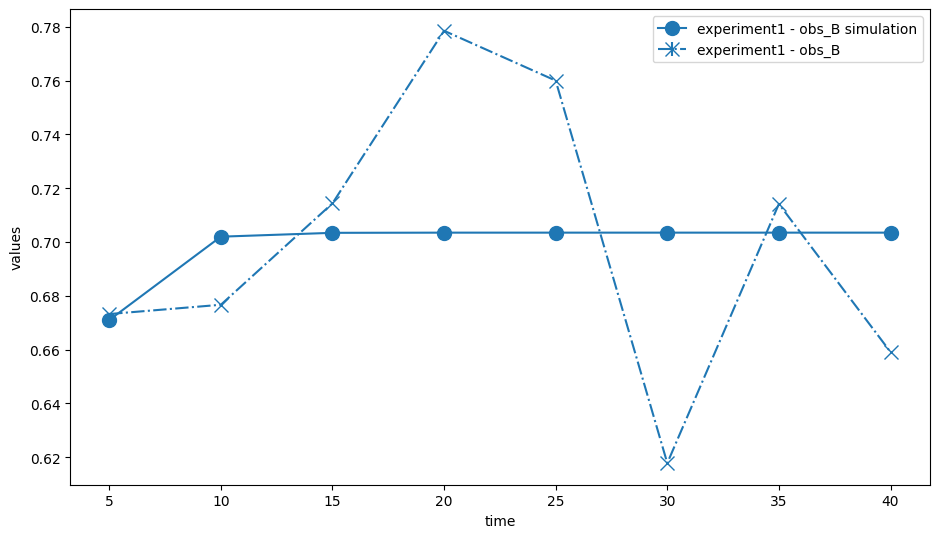

In [4]:
petab_problem = petab.Problem.from_yaml(petab_yaml)

ax = visualize_optimized_model_fit(
    petab_problem=petab_problem,
    result=result,
    pypesto_problem=problem,
)
plt.gcf().set_size_inches(9, 5)
plt.show();

### 3.2 Waterfall Plot

The **waterfall plot** shows the final objective value of every optimization start, sorted from best to worst. 

- A **flat plateau** at the left (many starts converging to the same minimum) → global optimum found with high confidence.
- **Many different values** → model may be **non-identifiable** or more starts are needed.

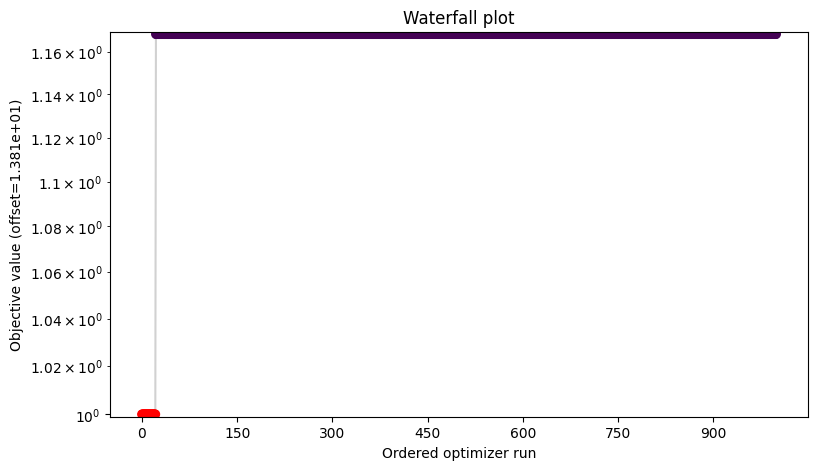

In [5]:
visualize.waterfall(result, size=(9, 5));

### 3.3 Parameter Plot

Each row shows one parameter; each dot is the value found by one start, colored by rank (best = darkest). 

- **Clustered dots** → well-identified parameter.
- **Spread-out dots** → poorly identified; UQ methods below will make this precise.

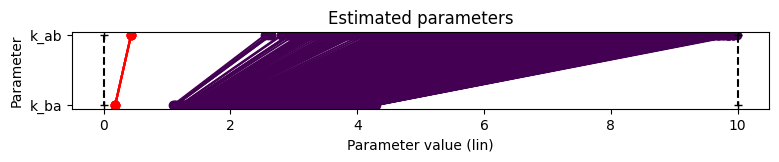

In [6]:
visualize.parameters(result, size=(9, 1));

---
## 4. Uncertainty Quantification via Laplace Approximation

The **Laplace approximation** is a quick way to estimate parameter uncertainty by approximating the posterior as a Gaussian centered at the optimum, with covariance given by the inverse Hessian of the negative log-likelihood. This is fast but can be inaccurate if the likelihood is non-Gaussian or parameters are correlated.

In [7]:
result_fim = profile.approximate_parameter_profile(
    problem=problem,
    result=copy.deepcopy(result),
    n_steps=10000
)

/Users/jonas.arruda/PyCharm Projects/Tutorial_BCML_2026/.venv/lib/python3.11/site-packages/pypesto/profile/approximate.py:101: RuntimeWarning: divide by zero encountered in log
  fvals = -np.log(ys)


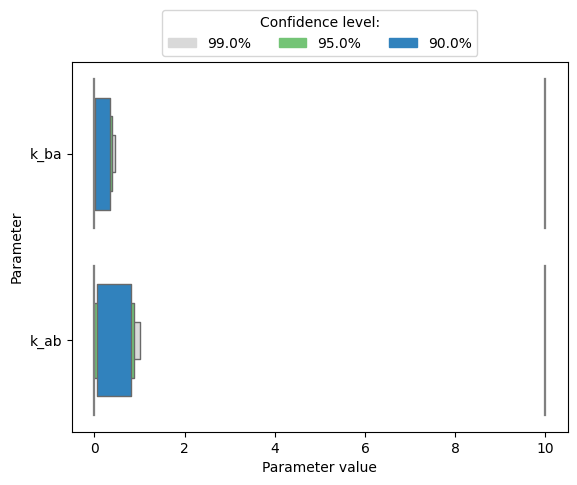

In [8]:
ax = pypesto.visualize.profile_nested_cis(
    result_fim,
    profile_indices=[0, 1],
    confidence_levels=[0.99, 0.95, 0.9],
    colors=[plt.cm.tab20c_r(x) for x in np.linspace(0, 1, 3)],
)

---
## 5. Profile Likelihood

**Profile likelihood** is a frequentist method for computing **confidence intervals** that correctly accounts for parameter correlations and non-linear effects — unlike the Laplace approximation.

### How it works
For each parameter $\theta_i$, we fix it at a grid of values and re-optimize all other parameters:
$$PL(\theta_i) = \max_{\theta_{j \neq i}} \; \mathcal{L}(\theta)$$

The **profile** traces out how much the likelihood degrades as we move away from the optimum. A confidence interval is defined by the likelihood ratio threshold:
$$\Delta \text{PL}(\theta_i) \leq \chi^2_{1, \alpha} / 2$$

With `whole_path=True`, the profile is computed in both directions from the optimum for a complete picture.

In [9]:
profile_options = profile.ProfileOptions(whole_path=True)

result_profile = profile.parameter_profile(
    problem=problem,
    result=copy.deepcopy(result),
    optimizer=pypesto.optimize.FidesOptimizer(verbose=0),
    engine=pypesto.engine.MultiProcessEngine(),
    profile_options=profile_options,
)

Engine will use up to 10 processes (= CPU count).
  0%|          | 0/4 [00:00<?, ?it/s]Next guess for k_ba in direction -1 is 0.1752. Step size: -0.0071.
Next guess for k_ba in direction 1 is 0.1896. Step size: 0.0073.
Next guess for k_ab in direction 1 is 0.4491. Step size: 0.0165.
Next guess for k_ab in direction -1 is 0.4169. Step size: -0.0157.
Optimization successful for k_ba=0.1752. Start fval -12.705214, end fval -12.806718.
Next guess for k_ba in direction -1 is 0.1737. Step size: -0.0015.
Optimization successful for k_ba=0.1896. Start fval -12.705026, end fval -12.807131.
Optimization successful for k_ab=0.4169. Start fval -12.703980, end fval -12.806756.
Next guess for k_ab in direction -1 is 0.4136. Step size: -0.0033.
Next guess for k_ba in direction 1 is 0.1914. Step size: 0.0018.
Optimization successful for k_ab=0.4491. Start fval -12.704752, end fval -12.807072.
Next guess for k_ab in direction 1 is 0.4531. Step size: 0.0040.
Optimization successful for k_ba=0.1737. Star

### 5.1 Profile Likelihood Plots

Each panel shows the profile for one parameter.

- **Clear maximum with finite bounds** → identifiable parameter.
- **Profile that never rises above the threshold** → **structurally non-identifiable** (flat profile) or **practically non-identifiable** (the confidence interval extends to the parameter bound).

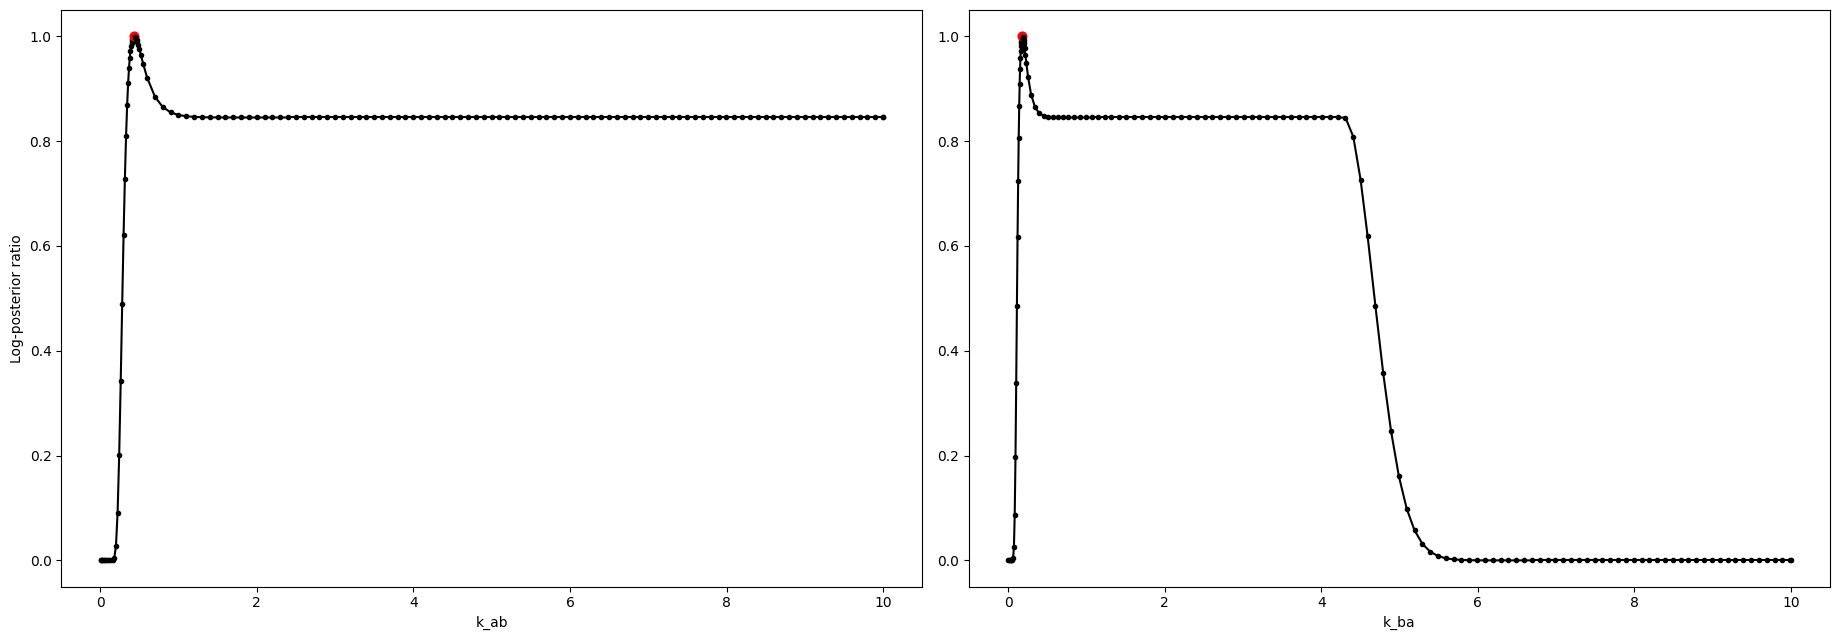

In [10]:
ax = visualize.profiles(result_profile, quality_colors=True);

### 5.2 Confidence Intervals from Profiles

A compact alternative view: confidence intervals for selected parameters at multiple confidence levels (90 %, 95 %, 99 %). This makes it easy to compare the uncertainty widths across parameters. Note that intervals are not necessarily symmetric around the optimum due to non-linearities in the likelihood.

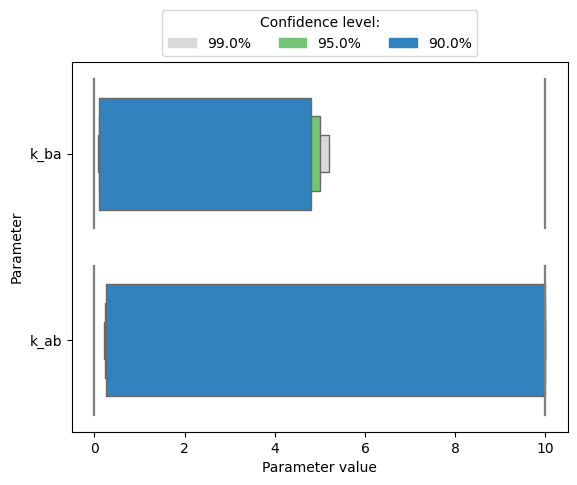

In [11]:
ax = pypesto.visualize.profile_nested_cis(
    result_profile,
    profile_indices=[0, 1],
    confidence_levels=[0.99, 0.95, 0.90],
    colors=[plt.cm.tab20c_r(x) for x in np.linspace(0, 1, 3)],
);

---
## 6. Bayesian Inference via MCMC Sampling

Where profile likelihood gives confidence intervals parameter-by-parameter, **MCMC sampling** characterizes the full joint posterior distribution $p(\theta \mid \text{data})$.


Here we use:
- **`AdaptiveMetropolisSampler`** — tunes the proposal covariance on-the-fly.
- **`AdaptiveParallelTemperingSampler`** — manages 5 temperature chains and adapts the temperature ladder.

> **Note:** We pass `result=result` so the chains are initialized near the optimum found earlier, which speeds up convergence.

In [12]:
sampler = sample.AdaptiveParallelTemperingSampler(
    internal_sampler=sample.AdaptiveMetropolisSampler(),
    n_chains=3,
)

result = sample.sample(
    problem,
    n_samples=10000,
    sampler=sampler,
    result=result,
    warm_start=0,  # warm-start from the optimization result
    filename=None,
)

Initializing betas with "near-exponential decay".
Sampling initial points from prior.
Initializing parallel chains with a combination of the starting point and prior samples with weight: 0.9.
100%|██████████| 10000/10000 [00:05<00:00, 1992.99it/s]
Elapsed time: 5.015394


### 6.1 Sampling Scatter Plot

The **scatter matrix** shows all pairwise marginals of the posterior. This can reveal correlations and potential multimodality that a profile likelihood analysis (which looks at parameters one at a time) may miss. In a small sample size regime, the using a Bayesian approach can be advantageous as it incorporates prior information and provides a full posterior distribution, which can be more informative than point estimates and confidence intervals from frequentist methods.

/Users/jonas.arruda/PyCharm Projects/Tutorial_BCML_2026/.venv/lib/python3.11/site-packages/pypesto/visualize/sampling.py:1221: UserWarning: Burn in index not found in the results, the full chain will be shown.
You may want to use, e.g., `pypesto.sample.geweke_test`.
  nr_params, params_fval, theta_lb, theta_ub, _ = get_data_to_plot(


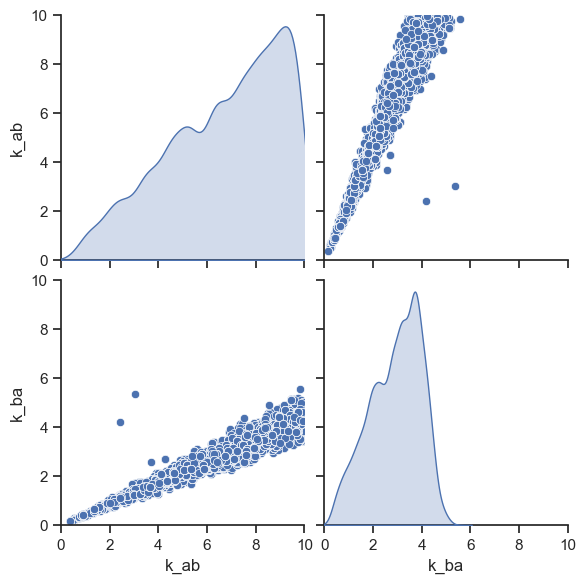

In [13]:
visualize.sampling_scatter(result)
plt.gcf().set_size_inches(6, 6)
plt.show();

The **optimization starts** (dots) should fall within the high-density region of the posterior. We see that just looking at optimal points we underestimate uncertainty, as the MCMC samples spread out much more than the optimization results. This is a common scenario in non-convex problems where the likelihood landscape has multiple modes or flat regions.

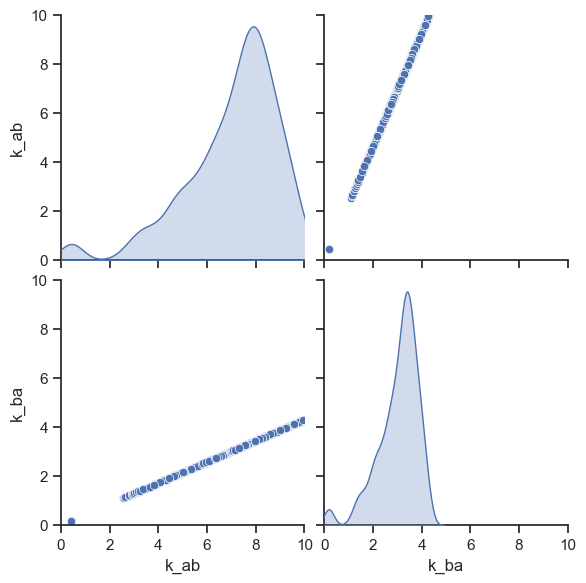

In [14]:
visualize.optimization_scatter(result, show_bounds=True)
plt.gcf().set_size_inches(6, 6)
plt.show();

### 6.2 Marginal Credible Intervals

Marginal **credible intervals** (Bayesian analog of confidence intervals) at 90 %, 95 %, and 99 % for each parameter, derived from the MCMC samples.

Geweke burn-in index: 0


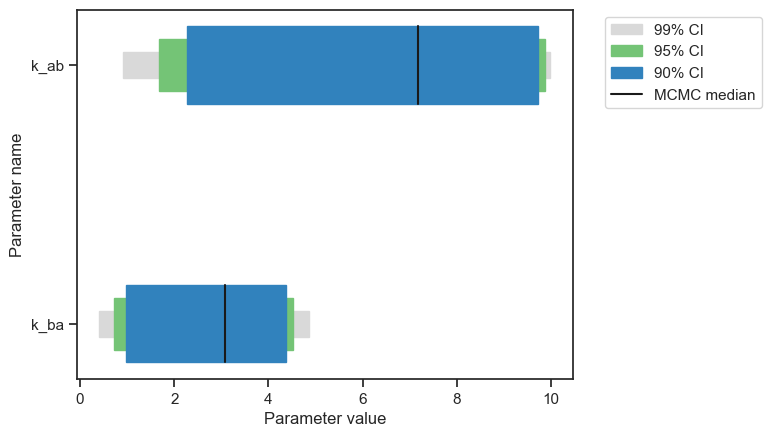

In [15]:
ax = visualize.sampling_parameter_cis(result, alpha=[99, 95, 90]);

## 7 Posterior Predictive Uncertainty Propagation

Bayesian inference gives us a full posterior distribution over parameters, which we can propagate through the model to obtain **posterior predictive distributions** for any quantity of interest (e.g., model trajectories, observables). This is a powerful way to quantify uncertainty in model predictions due to parameter uncertainty.

In [16]:
from pypesto.ensemble import Ensemble
from pypesto.predict import AmiciPredictor

ensemble = Ensemble.from_sample(
    result,
    x_names=problem.x_names,
    lower_bound=problem.lb,
    upper_bound=problem.ub,
)

In [17]:
# AmiciPredictor wraps the AMICI objective so it can be called with arbitrary
# parameter vectors and returns (timepoints, observable_trajectories).
predictor = AmiciPredictor(problem.objective)

ensemble_prediction = ensemble.predict(
    predictor,
    prediction_id="condition_0",
    engine=pypesto.engine.MultiProcessEngine(),
)
print("Predictions complete.")

Engine will use up to 10 processes (= CPU count).
100%|██████████| 10/10 [00:03<00:00,  2.88it/s]

Predictions complete.


In [18]:
# add assumed noise on top
for o in ensemble_prediction.prediction_results:
    o.conditions[0].output = o.conditions[0].output + np.random.normal(0, 0.05, size=len(o.conditions[0].output))

### 7.1 Trajectory Uncertainty Bands

`sampling_prediction_trajectories` plots **credible bands** for each observable in each experimental condition. The dark band is the median; the shaded regions are the 50 % and 95 % credible intervals across the ensemble.

Overlaying the measured data on the same axes shows how well the posterior predictive covers the observations — a quick sanity check for model adequacy.

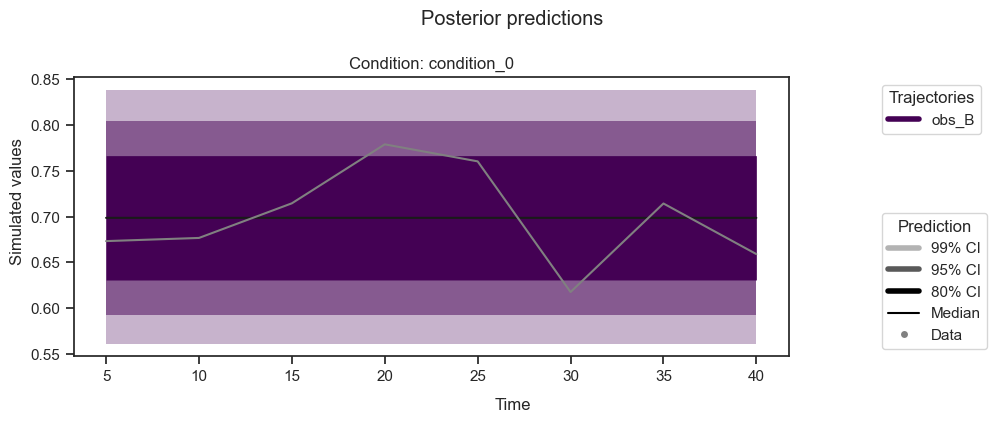

In [19]:
# Credible bands
axes = visualize.sampling_prediction_trajectories(
    ensemble_prediction,
    levels=[99, 95, 80],
    size=(10, 4),
    axis_label_padding=120,
    measurement_df=petab_problem.measurement_df,
    title='Posterior predictions',
)

# Overlay the raw measurements from the PEtab problem
measurements = petab_problem.measurement_df
axes[0, 0].plot(measurements["time"], measurements["measurement"],
            color="grey", zorder=5, label="data")

plt.tight_layout()
plt.show();

---
## Summary

In this tutorial we:

1. **Loaded** a mechanistic model and data via the PEtab standard.
2. **Estimated** parameters using multi-start optimization with Fides, and checked parameters with waterfall and parameter plots.
3. **Computed profile likelihoods** to obtain frequentist confidence intervals for each parameter.
4. **Ran MCMC sampling** (adaptive parallel tempering) to obtain the full Bayesian posterior.
5. **Ensemble predictions**: propagate parameter uncertainty through model predictions.

### Where to go next

- [pyPESTO documentation](https://pypesto.readthedocs.io)
- [PEtab documentation](https://petab.readthedocs.io)
- **Model selection**: compare models using AIC/BIC tools.